# Linear Regression

In [2]:
import pandas as pd
df=pd.read_csv("Downloads/student_scores - student_scores.csv")
df.head()

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


In [4]:
df.shape

(25, 2)

In [3]:
df.describe()

,Hours,Scores
count,25.000000,25.000000
mean,5.012000,51.480000
std,2.525094,25.286887
min,1.100000,17.000000
25%,2.700000,30.000000
50%,4.800000,47.000000
75%,7.400000,75.000000
max,9.200000,95.000000


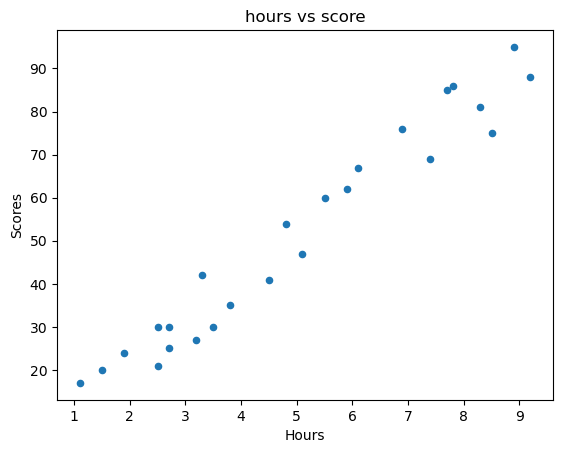

In [8]:
import matplotlib.pyplot as plt 
df.plot.scatter(x="Hours",y="Scores",title="hours vs score")
plt.show()


Graph → "Koi relationship hai?"

Correlation → "Relationship kitna strong hai?"

In [3]:
df.corr()

,Hours,Scores
Hours,1.000000,0.976191
Scores,0.976191,1.000000


# Data Preprocessing

In [22]:
X=df["Hours"].values.reshape(-1,1)
Y=df["Scores"].values.reshape(-1,1)
print(X.shape)
print(Y.shape)

(25, 1)
(25, 1)


In [23]:
from sklearn.model_selection import train_test_split
SEED=42
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=SEED)
print("X_train shape:",X_train.shape)
print("X_test shape:",X_test.shape)
print("y_train shape:", Y_train.shape)
print("y_test shape:", Y_test.shape)

X_train shape: (20, 1)
X_test shape: (5, 1)
y_train shape: (20, 1)
y_test shape: (5, 1)


In [24]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()
regression.fit(X_train, Y_train)
print("intercept(b):",regression.intercept_)
print("slope(m):",regression.coef_)

intercept(b): [2.82689235]
slope(m): [[9.68207815]]


In [29]:
Y_pred= regression.predict(X_test)
print(y_pred)

[[83.18814104]
 [27.03208774]
 [27.03208774]
 [69.63323162]
 [59.95115347]]


In [30]:
df_preds=pd.DataFrame({"Actual":Y_test.squeeze(),"predicted": Y_pred.squeeze()})
print(df_preds)

   Actual  predicted
0      81  83.188141
1      30  27.032088
2      21  27.032088
3      76  69.633232
4      62  59.951153


In [34]:
from sklearn.metrics import mean_squared_error,mean_absolute_error
import numpy as np 
mae=mean_absolute_error(Y_test,Y_pred)
mse=mean_squared_error(Y_test,Y_pred)
rmse=np.sqrt(mse)
print(f'MAE:  {mae:.2f}')
print(f'MSE:  {mse:.2f}')
print(f'RMSE: {rmse:.2f}')

MAE:  3.92
MSE:  18.94
RMSE: 4.35


# Multiple Linear Regression

In [2]:
import pandas as pd 
df=pd.read_csv("Downloads/petrol_consumption-master/petrol_consumption-master/data/petrol_consumption.csv")
df.head()

,Petrol_tax,Average_income,Paved_Highways,Population_Driver_licence(%),Petrol_Consumption
0,9.0,3571,1976,0.525,541
1,9.0,4092,1250,0.572,524
2,9.0,3865,1586,0.580,561
3,7.5,4870,2351,0.529,414
4,8.0,4399,431,0.544,410


In [4]:
df.shape

(48, 5)

In [5]:
X = df[['Petrol_tax', 'Average_income', 'Paved_Highways', 'Population_Driver_licence(%)']]
y = df['Petrol_Consumption']

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [11]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [12]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
y_pred = regressor.predict(X_test)

In [14]:
df_results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(df_results)

    Actual   Predicted
29     534  469.391989
4      410  545.645464
26     577  589.668394
30     571  569.730413
32     577  649.774809
37     704  646.631164
34     487  511.608148
40     587  672.475177
7      467  502.074782
10     580  501.270734


In [16]:
from sklearn import metrics
import numpy as np
print('Mean Absolute Error (MAE):', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error (MSE):', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error (RMSE):', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Mean Absolute Error (MAE): 56.822247478964734
Mean Squared Error (MSE): 4666.34478758837
Root Mean Squared Error (RMSE): 68.31064915215175


In [17]:
print('R-Squared Score:', metrics.r2_score(y_test, y_pred))

R-Squared Score: 0.20361932410121608


In [18]:
from sklearn.ensemble import RandomForestRegressor

# Model banaya (sirf 20 trees ke sath taake overfit na ho)
rf_reg = RandomForestRegressor(n_estimators=20, random_state=0)

# Train kiya
rf_reg.fit(X_train, y_train)

# Prediction
y_pred_rf = rf_reg.predict(X_test)

# Score check karo
from sklearn import metrics
print('New R-Squared:', metrics.r2_score(y_test, y_pred_rf))

New R-Squared: 0.28044885688734766


<Axes: >

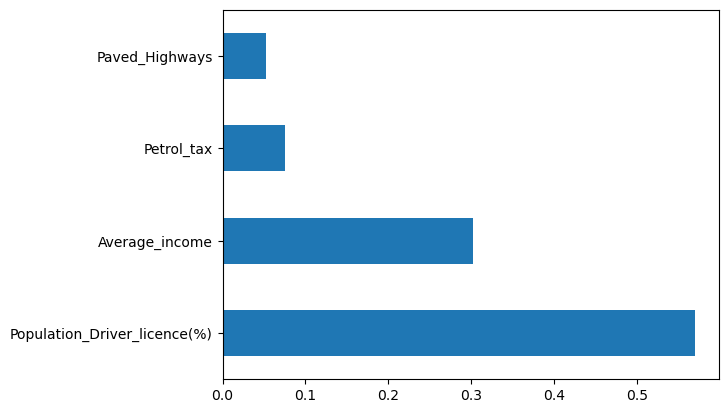

In [19]:
import pandas as pd

# Har feature ki importance nikalna
importances = pd.Series(rf_reg.feature_importances_, index=['Petrol_tax', 'Average_income', 'Paved_Highways', 'Population_Driver_licence(%)'])
importances.nlargest(4).plot(kind='barh')

In [20]:
# Hum model ko thora control karenge taake wo overfit na ho
rf_tuned = RandomForestRegressor(
    n_estimators=50,      # Trees thore barha dete hain (20 se 50)
    max_depth=3,          # Har tree ko bohot gehra nahi jane dena (Small data ke liye depth kam rakhte hain)
    min_samples_split=5,  # Aik node ko tab hi split karo agar us mein 5 samples hon
    random_state=0
)

# Tuned model ko train karo
rf_tuned.fit(X_train, y_train)

# Prediction
y_pred_tuned = rf_tuned.predict(X_test)

# Naya Score check karo
print('Tuned R-Squared:', metrics.r2_score(y_test, y_pred_tuned))

Tuned R-Squared: 0.3474750872672824
